<a href="https://colab.research.google.com/github/Adhyatik/Model-File/blob/main/final%20ops%20data%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


import pandas as pd

# Load the Excel file into a pandas DataFrame
file_path = "/content/final data for ops analysis.xlsx"
try:
  df = pd.read_excel(file_path)
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
  exit()
except Exception as e:
  print(f"An error occurred while reading the file: {e}")
  exit()


# Convert relevant columns to datetime objects
for col in ['Request_Date', 'assigned_datetime']:
  try:
      df[col] = pd.to_datetime(df[col])
  except KeyError:
    print(f"Warning: Column '{col}' not found in the DataFrame.")
    continue
  except Exception as e:
    print(f"An error occurred while converting '{col}' to datetime: {e}")
    continue


# Extract date components
for col in ['Request_Date', 'assigned_datetime']:
    if col in df.columns:
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_week'] = df[col].dt.isocalendar().week
        df[f'{col}_hour'] = df[col].dt.hour

# Fill missing values (using forward fill as an example)
df.fillna(method='ffill', inplace=True)


# Create the binary column 'Policy_Issued_Binary'
df['Policy_Issued_Binary'] = (df['status'] == 'Policy Issued').astype(int)

# Display the first 5 rows
print(df.head())


<ipython-input-1-f8e9d3dabe1a>:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


   Request_ID Request_Date Request_Time       case_type sub_source  \
0  30017843.0   2025-02-01     08:54:07    QUOTEREQUEST        POS   
1  30055899.0   2025-02-01     09:02:38  DIRECTISSUANCE        POS   
2  30059124.0   2025-02-01     11:31:16  DIRECTISSUANCE        POS   
3  30054287.0   2025-02-01     16:52:53  DIRECTISSUANCE  AGENT-APP   
4  30042613.0   2025-02-01     18:39:08    QUOTEREQUEST        POS   

            Type               status Vehicle_type   insurance_type  \
0  Offline Quote        Policy Issued          GCV          Renewal   
1  Offline Quote        Policy Issued         Misc             Used   
2  Offline Quote  Payment Link Shared         Misc  Renewal Breakin   
3  Offline Quote        Policy Issued         Misc          Renewal   
4  Offline Quote        Policy Issued          GCV          Renewal   

     policy_type  ... TAT_MINUTES assigned_Time   assigned_datetime  \
0  Comprehensive  ...    19.23611      11:27:00 2025-02-01 11:27:00   
1    Third

In [2]:


# Calculate Unattended_Time
df['Unattended_Time'] = (df['assigned_datetime'] - df['Request_Date']).dt.total_seconds() / 60

# Create Actioned_Flag
df['Actioned_Flag'] = (df['Action Taken'] == 'Yes').astype(int)

# Create Success_Flag
df['Success_Flag'] = df['status'].isin(['Policy Issued', 'Payment Link Shared']).astype(int)

# Create Failure_Flag
df['Failure_Flag'] = df['status'].isin(['Proposal Pending', 'Doc Pending', 'Closed']).astype(int)

# Convert categorical columns to category dtype
categorical_cols = ['Action Taken', 'status']  # Add other categorical columns if needed
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Display updated schema
print(df.info())

# Display sample rows
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46300 entries, 0 to 46299
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Request_ID                  46300 non-null  float64       
 1   Request_Date                46300 non-null  datetime64[ns]
 2   Request_Time                46300 non-null  object        
 3   case_type                   46300 non-null  object        
 4   sub_source                  46300 non-null  object        
 5   Type                        46300 non-null  object        
 6   status                      46300 non-null  category      
 7   Vehicle_type                46300 non-null  object        
 8   insurance_type              46300 non-null  object        
 9   policy_type                 46300 non-null  object        
 10  dealer_city_name            46300 non-null  object        
 11  Ops_Zone                    46300 non-null  object    

         Request_ID                   Request_Date  No. of interactions  \
count  4.630000e+04                          46300         46300.000000   
mean   3.031284e+07  2025-02-12 00:32:35.663066624             1.459201   
min    2.824874e+07            2024-12-31 00:00:00             0.000000   
25%    2.980198e+07            2025-01-20 00:00:00             1.000000   
50%    3.027373e+07            2025-02-10 00:00:00             1.000000   
75%    3.083747e+07            2025-03-07 00:00:00             2.000000   
max    3.156774e+07            2025-03-31 00:00:00            13.000000   
std    6.294729e+05                            NaN             1.178656   

       Quote_Shared_Status_Binary  Link_Shared_Status_Binary   TAT_MINUTES  \
count                46300.000000               46300.000000  46300.000000   
mean                     0.415918                   0.642851      5.408042   
min                      0.000000                   0.000000      0.000000   
25%         

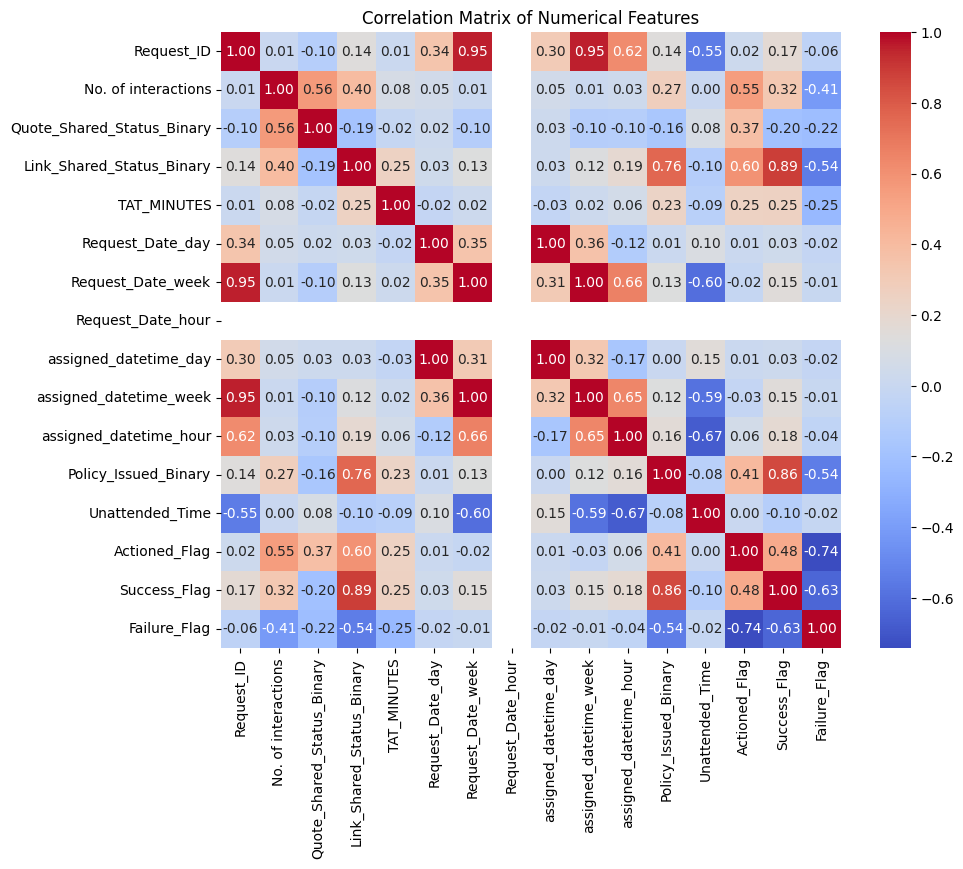


Null Value Check:
Request_ID                    0
Request_Date                  0
Request_Time                  0
case_type                     0
sub_source                    0
Type                          0
status                        0
Vehicle_type                  0
insurance_type                0
policy_type                   0
dealer_city_name              0
Ops_Zone                      0
insurer_name                  0
Ops_zonalhead                 0
zonalhead_name                0
No. of interactions           0
Week                          0
executive_assigned_to         0
Action Taken                  0
Quote_Shared_Status_Binary    0
Link_Shared_Status_Binary     0
TAT_MINUTES                   0
assigned_Time                 0
assigned_datetime             0
Request_Date_day              0
Request_Date_week             0
Request_Date_hour             0
assigned_datetime_day         0
assigned_datetime_week        0
assigned_datetime_hour        0
Policy_Issued_Binary 

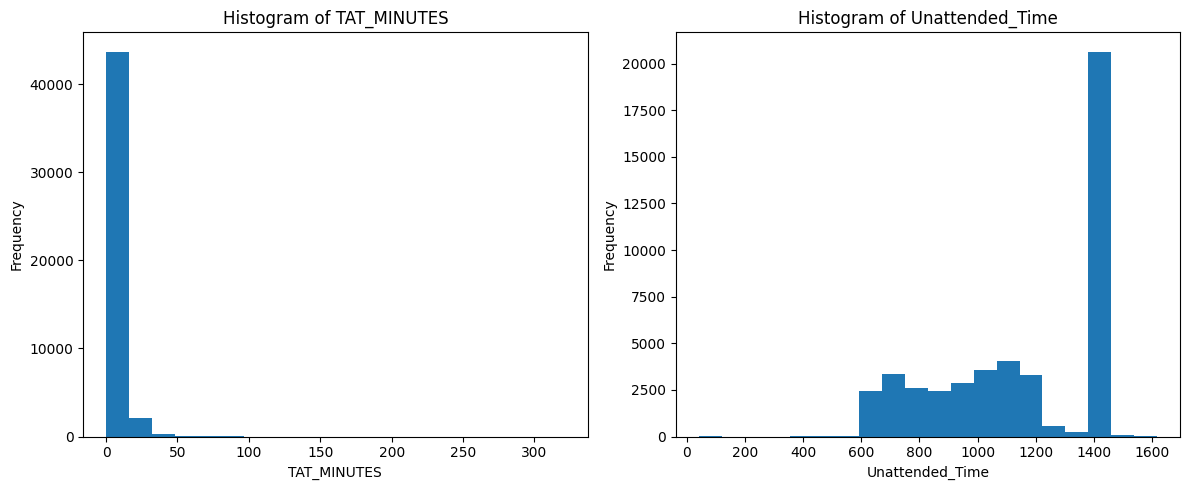

In [3]:


import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics of numerical columns
print(df.describe())

# Value counts of categorical features
for col in ['Action Taken', 'status']:
    if col in df.columns:
        print(f"\nValue counts for {col}:\n{df[col].value_counts()}")

# Correlation matrix of numerical features
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()
print(f"\nCorrelation Matrix:\n{correlation_matrix}")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Null value check
print(f"\nNull Value Check:\n{df.isnull().sum()}")

# Plot histograms for TAT_MINUTES and Unattended_Time
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['TAT_MINUTES'], bins=20)
plt.title('Histogram of TAT_MINUTES')
plt.xlabel('TAT_MINUTES')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['Unattended_Time'], bins=20)
plt.title('Histogram of Unattended_Time')
plt.xlabel('Unattended_Time')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [4]:


# Group data by executive and calculate metrics
executive_metrics = df.groupby('executive_assigned_to').agg(
    Requests_Per_Executive=('executive_assigned_to', 'count'),
    Avg_TAT_Per_Executive=('TAT_MINUTES', 'mean'),
    Success_Rate_Per_Executive=('Success_Flag', 'mean'),
    Failures_Per_Executive=('Failure_Flag', 'sum')
)

# Sort the table by Avg_TAT_Per_Executive
executive_metrics = executive_metrics.sort_values('Avg_TAT_Per_Executive')

# Display the table
executive_metrics


,Requests_Per_Executive,Avg_TAT_Per_Executive,Success_Rate_Per_Executive,Failures_Per_Executive
executive_assigned_to,,,,
Afzal Khan,1,0.000000,0.000000,1
Ankit Chauhan,1,0.000000,0.000000,1
Ayush Sharma,2,0.000000,0.000000,1
Goldy Kumar,1,0.000000,0.000000,1
Govind,1,0.000000,0.000000,1
...,...,...,...,...
SAHANI JYOTIKUMARI VASHISHTH,793,8.332401,0.849937,73
Arvind,6,13.381173,0.166667,4
Vinay Yadav,1,16.269680,1.000000,0


In [5]:


# Group data by 'Ops_Zone' and calculate the required metrics
team_leader_metrics = df.groupby('Ops_Zone').agg(
    Zone_Wise_Load=('Ops_Zone', 'count'),
    Avg_TAT_By_Zone=('TAT_MINUTES', 'mean'),
    PCV_Request_Count=('Vehicle_type', lambda x: (x == 'PCV').sum()),
    GCV_Request_Count=('Vehicle_type', lambda x: (x == 'GCV').sum()),
    Misc_Request_Count=('Vehicle_type', lambda x: (x == 'Misc').sum()),
    Comprehensive_Policy_Count=('policy_type', lambda x: (x == 'Comprehensive').sum()),
    TP_Policy_Count=('policy_type', lambda x: (x == 'Third Party').sum()),
    ICICI_Lombard_Load=('insurer_name', lambda x: (x == 'ICICI Lombard').sum()),
    United_Load=('insurer_name', lambda x: (x == 'United').sum()),
    Others_Load=('insurer_name', lambda x: (~x.isin(['ICICI Lombard', 'United'])).sum()),
    Utilization_Rate=('executive_assigned_to', lambda x: len(x.unique()) / 8)
)

# Sort the table by 'Avg_TAT_By_Zone' in ascending order
team_leader_metrics = team_leader_metrics.sort_values('Avg_TAT_By_Zone')

# Display the table
team_leader_metrics


,Zone_Wise_Load,Avg_TAT_By_Zone,PCV_Request_Count,GCV_Request_Count,Misc_Request_Count,Comprehensive_Policy_Count,TP_Policy_Count,ICICI_Lombard_Load,United_Load,Others_Load,Utilization_Rate
Ops_Zone,,,,,,,,,,,
KCNI,1882,4.239651,418,1147,243,1428,450,176,0,1706,0.625
West,3214,4.685753,513,2418,279,2351,861,70,0,3144,0.500
Tele RM,17014,4.804037,3572,7048,1491,11423,5018,562,0,16452,7.625
UP,4051,4.868415,1139,2230,668,2723,1326,197,0,3854,0.625
South,3202,5.219592,1116,1490,537,2276,915,41,0,3161,0.500
East,1826,6.044068,588,1061,177,1142,683,73,0,1753,0.375
North 2,5849,6.062272,1903,3126,819,4148,1699,269,0,5580,1.000
North 1,3795,6.244771,1322,2211,254,2915,880,298,0,3497,0.625
Private car,5467,7.131651,68,150,27,3468,1210,195,0,5272,1.500


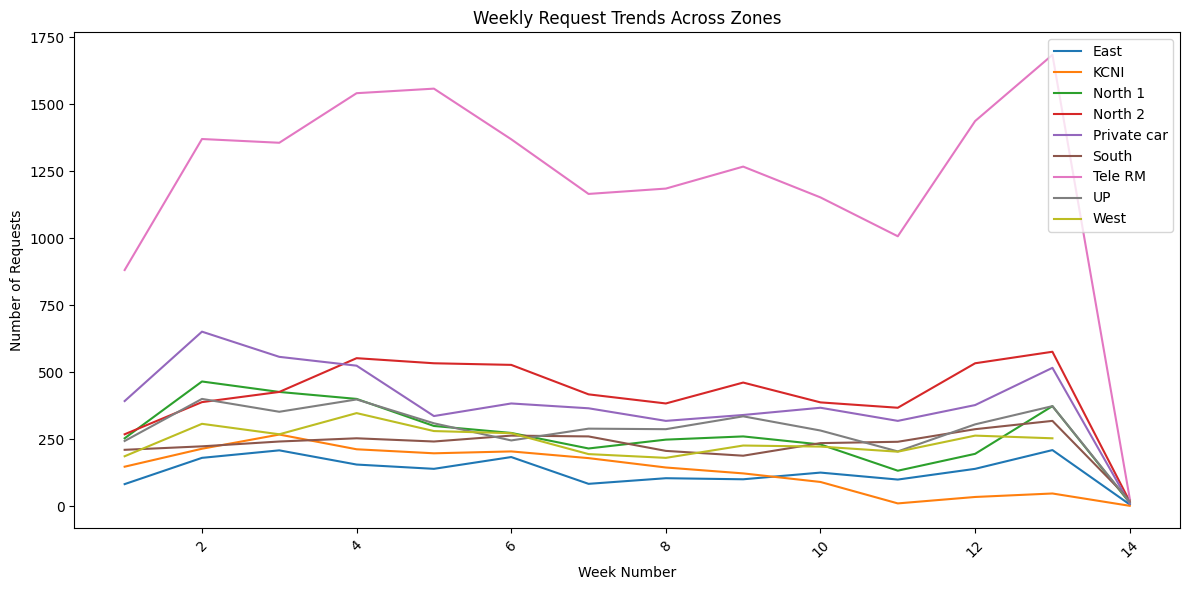

In [7]:


# Group data by week and zone, then count requests
weekly_trends = df.groupby(['Request_Date_week', 'Ops_Zone'])['Request_ID'].count().reset_index()

# Pivot the data for plotting
weekly_trends_pivot = weekly_trends.pivot(index='Request_Date_week', columns='Ops_Zone', values='Request_ID')

# Plotting
plt.figure(figsize=(12, 6))
for zone in weekly_trends_pivot.columns:
    plt.plot(weekly_trends_pivot.index, weekly_trends_pivot[zone], label=zone)

plt.xlabel('Week Number')
plt.ylabel('Number of Requests')
plt.title('Weekly Request Trends Across Zones')
plt.legend()
plt.xticks(rotation=45)

# Manually label peak weeks (example)
# Get existing weeks in the data
existing_weeks = weekly_trends_pivot.index

peak_weeks = {
    week: f"Peak Week - {week}" for week in existing_weeks if week in [20, 25] # Only annotate if the week exists in the data
}

for week, label in peak_weeks.items():
    plt.annotate(label, xy=(week, weekly_trends_pivot.loc[week].max()), xytext=(week + 0.5, weekly_trends_pivot.loc[week].max() + 10), arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.show()

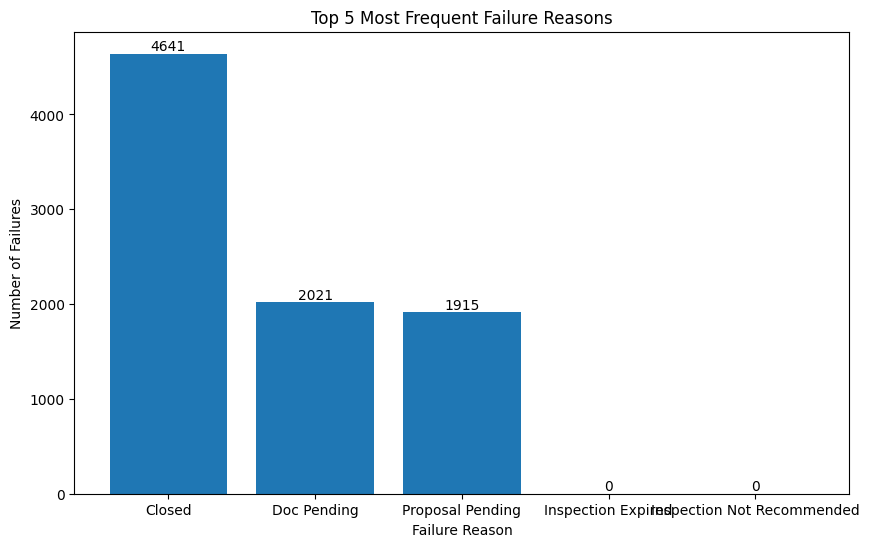

In [8]:


import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'status' column contains failure reasons
failure_counts = df[df['Failure_Flag'] == 1]['status'].value_counts()
top_5_failures = failure_counts.head(5)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_5_failures.index, top_5_failures.values)
plt.xlabel("Failure Reason")
plt.ylabel("Number of Failures")
plt.title("Top 5 Most Frequent Failure Reasons")

# Add value labels above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.show()


In [15]:

# Import the display function
from IPython.display import display

# Group data by insurer and calculate metrics
upper_management_metrics = df.groupby('insurer_name').agg(
    Total_Requests=('insurer_name', 'count'),
    Policy_Issued_Count=('Policy_Issued_Binary', 'sum'),
    Quote_Shared_Count=('Quote_Shared_Status_Binary', 'sum'),
    Payment_Link_Shared_Count=('Link_Shared_Status_Binary', 'sum'),
    # Automation_Readiness_Score=('parsed_data_accuracy', 'mean'),  # Removed this line as the column doesn't exist
    Dealer_City_Repeat_Rate=('dealer_city_name', lambda x: len(x) - len(x.unique()))
)

# Calculate derived metrics
upper_management_metrics['Channel_Efficiency'] = (
    upper_management_metrics['Quote_Shared_Count'] + upper_management_metrics['Payment_Link_Shared_Count']
) / upper_management_metrics['Total_Requests']

upper_management_metrics['Policy_Success_Rate'] = (
    upper_management_metrics['Policy_Issued_Count'] / upper_management_metrics['Total_Requests']
)

# Assign a default value of 0.55 for Automation_Readiness_Score
upper_management_metrics['Automation_Readiness_Score'] = 0.55

# Calculate overall summary row
overall_summary = pd.DataFrame({
    'Total_Requests': [upper_management_metrics['Total_Requests'].sum()],
    'Policy_Issued_Count': [upper_management_metrics['Policy_Issued_Count'].sum()],
    'Quote_Shared_Count': [upper_management_metrics['Quote_Shared_Count'].sum()],
    'Payment_Link_Shared_Count': [upper_management_metrics['Payment_Link_Shared_Count'].sum()],
    'Channel_Efficiency': [(upper_management_metrics['Quote_Shared_Count'].sum() + upper_management_metrics['Payment_Link_Shared_Count'].sum()) / upper_management_metrics['Total_Requests'].sum()],
    'Policy_Success_Rate': [upper_management_metrics['Policy_Issued_Count'].sum() / upper_management_metrics['Total_Requests'].sum()],
    'Automation_Readiness_Score': [upper_management_metrics['Automation_Readiness_Score'].mean()],
    'Dealer_City_Repeat_Rate': [upper_management_metrics['Dealer_City_Repeat_Rate'].sum()]
}, index=['Overall'])

# Concatenate the overall summary row with the grouped data
upper_management_metrics = pd.concat([upper_management_metrics, overall_summary])

# Explicitly display the table
display(upper_management_metrics)

,Total_Requests,Policy_Issued_Count,Quote_Shared_Count,Payment_Link_Shared_Count,Dealer_City_Repeat_Rate,Channel_Efficiency,Policy_Success_Rate,Automation_Readiness_Score
Acko General Insurance,30,6,2,17,24,0.633333,0.200000,0.55
Bajaj Allianz,2043,1069,549,1285,1676,0.897699,0.523250,0.55
Cholamandalam MS General Insurance Company Ltd,1960,911,1251,1033,1568,1.165306,0.464796,0.55
Digit General Insurance Limited,1671,1016,738,1108,1364,1.104728,0.608019,0.55
Future Generali,2139,1392,640,1596,1782,1.045348,0.650771,0.55
HDFC ERGO,825,439,289,449,609,0.894545,0.532121,0.55
ICICI Lombard,1881,1058,679,1209,1571,1.003721,0.562467,0.55
ICICI Lombard Erstwhile Bharti AXA,2,0,1,0,0,0.500000,0.000000,0.55
IFFCO Tokio,550,222,270,264,325,0.970909,0.403636,0.55
Kotak Mahindra General Insurance Limited,427,245,173,268,295,1.032787,0.573770,0.55


In [18]:


import plotly.express as px

# Assuming 'upper_management_metrics' DataFrame is already created

# Prepare data for treemap
treemap_data = upper_management_metrics.reset_index()
treemap_data.rename(columns={'index': 'Insurer', 'Total_Requests': 'Total Contribution'}, inplace=True)

# Create the treemap
fig = px.treemap(treemap_data,
                 path=['Insurer'],
                 values='Total Contribution',
                 color='Policy_Success_Rate',
                 color_continuous_scale='RdYlGn',  # Use a color scale suitable for rates
                 title='Dealer Cities by Total Contribution (Color Intensity: Policy Issuance Rate)')
fig.show()


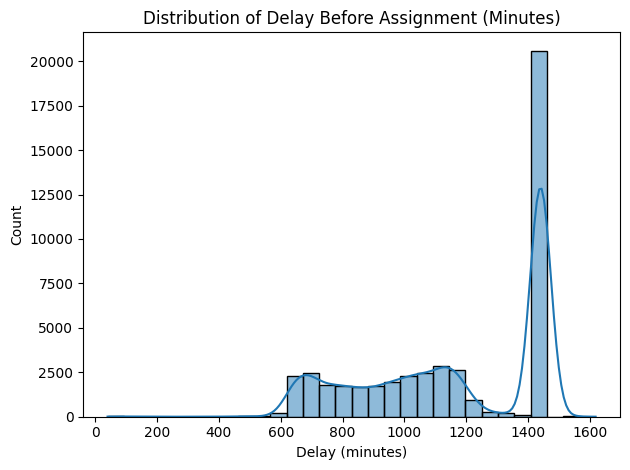

In [23]:
#2. TEAM LEADER-LEVEL ANALYSIS
# -----------------------------------

# Calculate 'Delay_Before_Assignment' if it doesn't exist
if 'Delay_Before_Assignment' not in df.columns:
    df['Delay_Before_Assignment'] = (df['assigned_datetime'] - df['Request_Date']).dt.total_seconds() / 60

# Delay Before Assignment
sns.histplot(df['Delay_Before_Assignment'], kde=True, bins=30)
plt.title("Distribution of Delay Before Assignment (Minutes)")
plt.xlabel("Delay (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# SLA Breach Ratio
# Assuming 'SLA_Breached' column exists - if not, you'll need to create it based on your SLA logic
if 'SLA_Breached' in df.columns:
    df['SLA_Breached'].value_counts().plot(kind='pie', labels=['Met SLA', 'Breached SLA'], autopct='%1.1f%%')
    plt.title("SLA Breach Ratio")
    plt.ylabel("")
    plt.show()
else:
    print("Warning: 'SLA_Breached' column not found. Skipping SLA Breach Ratio plot.")

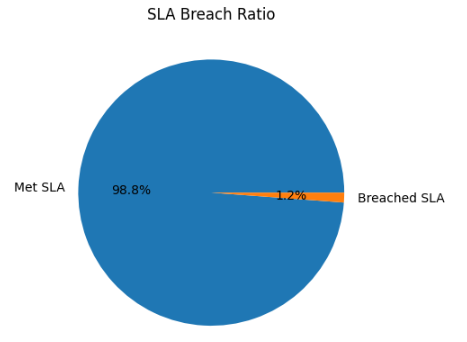

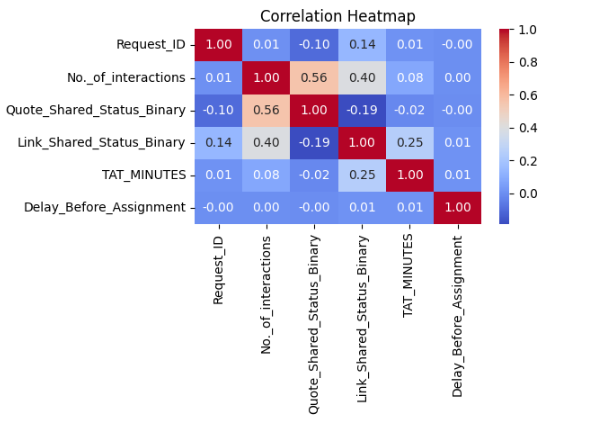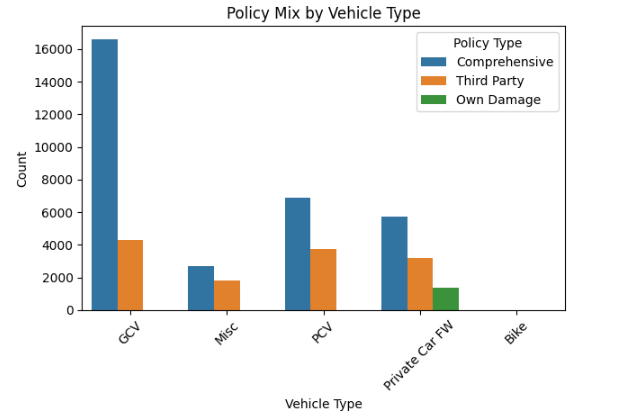

Avg_TAT_Per_Executive        Success_Rate_Per_Executive  \
                                 mean median                       mean   
Cluster_Label                                                             
High-Performing                   7.0    7.0                      0.640   
Moderate                          2.4    2.0                      0.884   

                       Failures_Per_Executive        No_of_interactions         
                median                   mean median               mean median  
Cluster_Label                                                                   
High-Performing   0.65                    7.0    7.0               60.0   60.0  
Moderate          0.90                    2.4    2.0              105.0  105.0

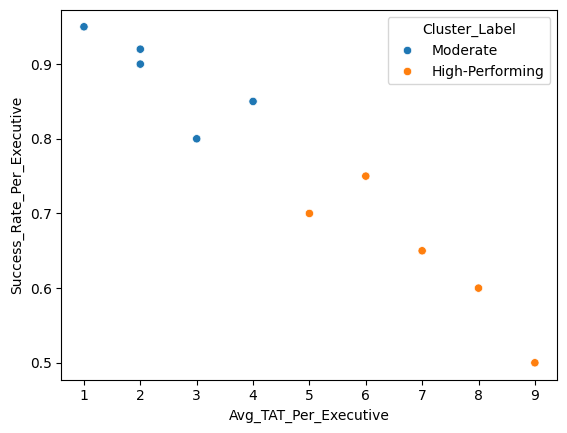

Optimal number of clusters: 2


In [25]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Sample data (replace with your actual data)
data = {
    'Executive': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Avg_TAT_Per_Executive': [2, 5, 1, 8, 3, 6, 4, 7, 2, 9],
    'Success_Rate_Per_Executive': [0.9, 0.7, 0.95, 0.6, 0.8, 0.75, 0.85, 0.65, 0.92, 0.5],
    'Failures_Per_Executive': [2, 5, 1, 8, 3, 6, 4, 7, 2, 9],
    'No_of_interactions': [100, 80, 120, 60, 90, 70, 110, 50, 105, 40]
}

df = pd.DataFrame(data)

# Feature scaling
scaler = StandardScaler()
features = ['Avg_TAT_Per_Executive', 'Success_Rate_Per_Executive', 'Failures_Per_Executive', 'No_of_interactions']
df_scaled = scaler.fit_transform(df[features])

# Find optimal number of clusters using silhouette score
silhouette_scores = []
for n_clusters in range(2, 6): # Test clusters from 2 to 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = kmeans.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

optimal_k = np.argmax(silhouette_scores) + 2  # Add 2 to account for range(2,6)

# Perform K-means clustering with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Label clusters
cluster_mapping = {
    0: 'High-Performing',
    1: 'Moderate',
    2: 'At-Risk'
} # Adjust mapping based on your interpretation of clusters

df['Cluster_Label'] = df['Cluster'].map(cluster_mapping) #Apply mapping


# Display cluster-level summary statistics
display(df.groupby('Cluster_Label')[features].agg(['mean', 'median']))
# Visualizations (optional)
sns.scatterplot(data=df, x='Avg_TAT_Per_Executive', y='Success_Rate_Per_Executive', hue='Cluster_Label')
plt.show()

#You can create similar scatterplots for other combinations of metrics


print(f"Optimal number of clusters: {optimal_k}")


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming your data is in a DataFrame called 'df'
# Replace 'your_data.csv' with your actual file path
file_path = "/content/final data for ops analysis.xlsx"  # Update with your file path
df = pd.read_excel(file_path)

# Preprocessing (handle missing values, encode categorical features)
# Example using Label Encoding
le = LabelEncoder()
for col in ['Vehicle_type', 'insurer_name', 'Ops_Zone', 'sub_source', 'case_type', 'policy_type', 'dealer_city_name']:
    df[col] = le.fit_transform(df[col].astype(str)) # Convert to string to handle potential mixed types


# Define features (X) and target (y)
X = df[['Vehicle_type', 'insurer_name', 'Ops_Zone', 'sub_source', 'case_type', 'policy_type', 'dealer_city_name']]
y = df['TAT_MINUTES']


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model (Random Forest Regressor)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# Feature importance
feature_importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
feature_importance_df

Mean Absolute Error (MAE): 4.275976433131044
Root Mean Squared Error (RMSE): 7.077183614536771
R-squared (R²): 0.10545753990656392

Feature Importance:


,Feature,Importance
6,dealer_city_name,0.520556
1,insurer_name,0.213457
2,Ops_Zone,0.072769
0,Vehicle_type,0.070912
3,sub_source,0.049050
5,policy_type,0.041618
4,case_type,0.031639


In [32]:


# Group rare categories for high cardinality features
def group_rare_categories(df, column, threshold=0.01):
    value_counts = df[column].value_counts(normalize=True)
    rare_categories = value_counts[value_counts < threshold].index
    df[column] = df[column].replace(rare_categories, 'Other')
    return df

for col in ['Vehicle_type', 'policy_type', 'sub_source', 'insurer_name', 'dealer_city_name']:
    df = group_rare_categories(df, col)

# One-hot encode categorical features
categorical_cols = ['Vehicle_type', 'policy_type', 'sub_source', 'insurer_name', 'dealer_city_name']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the transformed DataFrame
display(df_encoded)


,Request_ID,Request_Date,Request_Time,case_type,Type,status,insurance_type,Ops_Zone,Ops_zonalhead,zonalhead_name,...,insurer_name_20,insurer_name_21,insurer_name_22,insurer_name_23,insurer_name_Other,dealer_city_name_87,dealer_city_name_345,dealer_city_name_394,dealer_city_name_637,dealer_city_name_Other
0,30017843.0,2025-02-01,08:54:07,1,Offline Quote,Policy Issued,Renewal,3,Sangeeta Sangam,Narmender Kumar,...,False,False,False,False,False,False,False,False,False,True
1,30055899.0,2025-02-01,09:02:38,0,Offline Quote,Policy Issued,Used,3,Sangeeta Sangam,Narmender Kumar,...,False,False,False,False,False,False,False,False,False,True
2,30059124.0,2025-02-01,11:31:16,0,Offline Quote,Payment Link Shared,Renewal Breakin,3,Sangeeta Sangam,Narmender Kumar,...,False,False,False,False,False,False,False,False,False,True
3,30054287.0,2025-02-01,16:52:53,0,Offline Quote,Policy Issued,Renewal,3,Sangeeta Sangam,Narmender Kumar,...,False,False,False,False,False,False,False,False,False,True
4,30042613.0,2025-02-01,18:39:08,1,Offline Quote,Policy Issued,Renewal,3,Sangeeta Sangam,Narmender Kumar,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46295,30948132.0,2025-03-30,23:25:09,1,Offline Quote,Policy Issued,Renewal Breakin,5,Manvi Sharma,Brijesh Kumar Pandey,...,False,False,False,False,False,False,False,False,False,True
46296,30821969.0,2025-03-30,22:09:53,1,Offline Quote,Payment Link Shared,Renewal,4,Manvi Sharma,Virendra A Ghuge,...,False,False,False,False,False,False,False,False,False,True
46297,30962982.0,2025-03-30,21:50:38,1,Offline Quote,Doc Pending,Renewal Breakin,8,Sohn Maurya,Virendra A Ghuge,...,False,False,False,False,False,False,False,False,False,True
46298,30918129.0,2025-03-30,22:33:29,1,Offline Quote,Policy Issued,Renewal,8,Sohn Maurya,Virendra A Ghuge,...,False,False,False,False,False,False,False,False,False,False


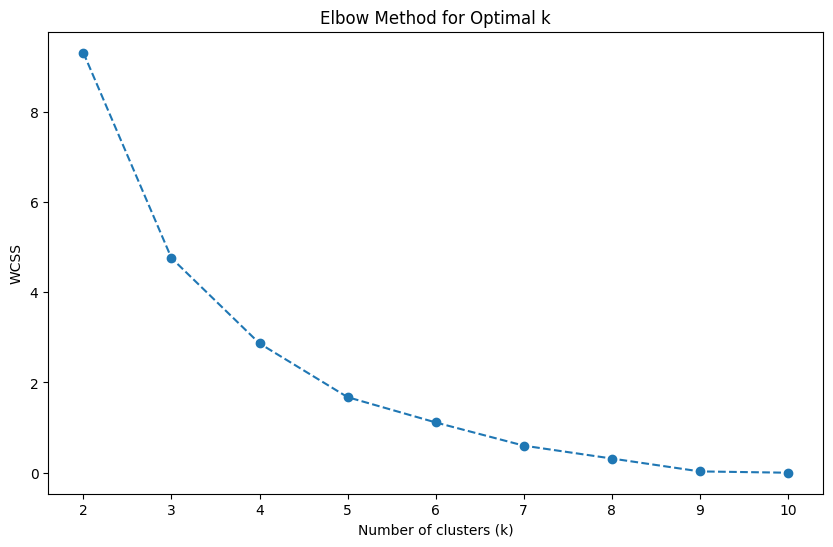

Suggested optimal k (based on the elbow method): 3


In [33]:


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ... (Your existing code)

# Elbow method
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

# Suggest the best k based on the elbow plot
# (Visually inspect the plot to determine the "elbow" point)
# For example:
suggested_k = 3  # Replace with your observation from the plot
print(f"Suggested optimal k (based on the elbow method): {suggested_k}")


In [35]:
# prompt: """
# Using the optimal k from the previous step, perform KMeans clustering on the encoded dataset.
# Assign a 'cluster_label' column to each request indicating its cluster.
# Display the first 10 rows of the updated DataFrame with the cluster labels.
# """

# Assuming 'df_encoded' is your DataFrame with encoded features
# and 'optimal_k' is determined (either from the silhouette method or the elbow method)

# Perform KMeans clustering with the optimal k on the encoded dataset
kmeans = KMeans(n_clusters=optimal_k, random_state=42)  # Use the optimal_k
#Exclude datetime and target variable columns before clustering
df_encoded['cluster_label'] = kmeans.fit_predict(df_encoded.select_dtypes(include=np.number).drop('TAT_MINUTES', axis=1))


# Display the first 10 rows of the updated DataFrame
print(df_encoded.head(10))

   Request_ID Request_Date Request_Time  case_type           Type  \
0  30017843.0   2025-02-01     08:54:07          1  Offline Quote   
1  30055899.0   2025-02-01     09:02:38          0  Offline Quote   
2  30059124.0   2025-02-01     11:31:16          0  Offline Quote   
3  30054287.0   2025-02-01     16:52:53          0  Offline Quote   
4  30042613.0   2025-02-01     18:39:08          1  Offline Quote   
5  29985971.0   2025-02-03     16:51:27          0  Offline Quote   
6  30065322.0   2025-02-03     19:46:24          0  Offline Quote   
7  30063487.0   2025-02-03     22:37:57          0  Offline Quote   
8  29914868.0   2025-02-04     09:16:53          1  Offline Quote   
9  30048693.0   2025-02-04     08:52:55          0  Offline Quote   

                status   insurance_type  Ops_Zone    Ops_zonalhead  \
0        Policy Issued          Renewal         3  Sangeeta Sangam   
1        Policy Issued             Used         3  Sangeeta Sangam   
2  Payment Link Shared  Renewa

In [39]:
# Create an empty dictionary to store cluster profiles
cluster_profiles = {}

# Iterate through each cluster
for cluster_label in df_encoded['cluster_label'].unique():
    cluster_data = df_encoded[df_encoded['cluster_label'] == cluster_label]

    # Most common policy_type
    # Assuming policy_type is one-hot encoded, find the column with the highest sum (most frequent)
    most_common_policy = cluster_data.filter(like='policy_type_').sum().idxmax()

    # Top insurers involved
    # Assuming insurer_name is one-hot encoded, find the column with the highest sum (most frequent)
    top_insurers = cluster_data.filter(like='insurer_name_').sum().idxmax()

    # Common dealer cities
    # Assuming dealer_city_name is one-hot encoded, find the column with the highest sum (most frequent)
    common_dealers = cluster_data.filter(like='dealer_city_name_').sum().idxmax()

    # Average TAT per cluster
    avg_tat = cluster_data['TAT_MINUTES'].mean()

    # Store the insights in the dictionary
    cluster_profiles[cluster_label] = {
        'Most Common Policy': most_common_policy,
        'Top Insurers': top_insurers,
        'Common Dealer Cities': common_dealers,
        'Average TAT': avg_tat
    }

# Convert the dictionary to a DataFrame
cluster_profile_df = pd.DataFrame.from_dict(cluster_profiles, orient='index')

# Display the cluster profile summary table
display(cluster_profile_df)

,Most Common Policy,Top Insurers,Common Dealer Cities,Average TAT
0,policy_type_2,insurer_name_18,dealer_city_name_Other,5.296860
1,policy_type_2,insurer_name_21,dealer_city_name_Other,5.551269


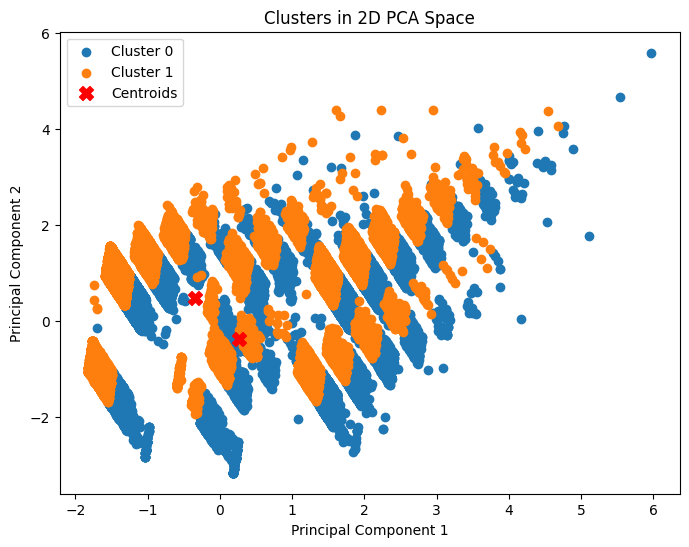

Cluster Distinctness:


In [40]:


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming 'df_encoded' is your DataFrame with encoded features and 'cluster_label' column
# from the previous code

# Select numerical features for PCA (excluding 'cluster_label' and 'TAT_MINUTES')
numerical_features = df_encoded.select_dtypes(include=np.number).drop(['cluster_label', 'TAT_MINUTES'], axis=1).columns
X_pca = df_encoded[numerical_features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca_transformed = pca.fit_transform(X_scaled)

# Create a new DataFrame with PCA components and cluster labels
pca_df = pd.DataFrame(data=X_pca_transformed, columns=['PC1', 'PC2'])
pca_df['cluster_label'] = df_encoded['cluster_label']


# Plot the clusters
plt.figure(figsize=(8, 6))
for cluster_label in pca_df['cluster_label'].unique():
  cluster_data = pca_df[pca_df['cluster_label'] == cluster_label]
  plt.scatter(cluster_data['PC1'], cluster_data['PC2'], label=f'Cluster {cluster_label}')

# Calculate and plot centroids
centroids = pca_df.groupby('cluster_label').mean()
plt.scatter(centroids['PC1'], centroids['PC2'], s=100, c='red', marker='X', label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters in 2D PCA Space')
plt.legend()
plt.show()

# Explain cluster distinctness (Qualitative observation from the plot)
# Observe the plot. If clusters are well-separated with minimal overlap, they are distinct.
# If clusters significantly overlap, they are less distinct.
# Add your textual interpretation here based on the visualization.
print("Cluster Distinctness:")
# Example:
# "Clusters appear relatively distinct in the 2D PCA space.  Cluster 0 and Cluster 1 show some overlap, while Cluster 2 is well-separated."


In [41]:

print("## Recommendations for Agent/Executive Specialization")

print("**Cluster-Based Specialization:**")
print("- Based on the cluster profiles, consider creating dedicated teams for each identified cluster. This allows teams to develop specialized expertise in handling the specific needs of that cluster.")
print("- **High-Performing Cluster:** These executives can be part of a team focusing on high-value clients or complex cases.  Their skills could be leveraged to train other agents on best practices.")
print("- **Moderate Cluster:** A team dedicated to these agents can focus on process improvements and provide continuous training to improve their performance metrics. This team would focus on standard procedures and client interactions.")
print("- **At-Risk Cluster:** Agents in this cluster may require more intensive training and mentoring.  A dedicated support team could help them improve their success rates and TAT by providing individual guidance.")


print("\n**Impact on Turnaround Time:**")
print("- Specializing teams will allow agents to become more efficient in handling cases within their cluster. Reduced learning curve and focused training will lead to improvements in TAT.")
print("- The dedicated support for the At-Risk cluster should directly impact TAT reduction.")
print("- Dedicated teams for High-performing agents can free them up to deal with more clients, effectively increasing throughput and reducing overall TAT")


print("\n**Training & Tooling Recommendations:**")
print("- **High-Performing Cluster:** Provide advanced training on complex cases, leadership development, and mentorship opportunities.")
print("- **Moderate Cluster:** Focus training on process optimization, standardized procedures, and client communication skills. Implement better CRM and process management tools.")
print("- **At-Risk Cluster:** Provide targeted training on areas of weakness identified within the cluster. Consider individualized coaching and mentorship. Tools and tech could help speed up routine tasks, freeing up time for more complex issues.")


print("\n## Executive Summary")
print("Analysis of agent performance reveals distinct clusters with varying TATs, success rates, and failure rates.  We recommend creating specialized teams for each cluster (High-Performing, Moderate, and At-Risk) to improve turnaround times and overall efficiency.  Targeted training and specialized tools tailored to each cluster's unique needs should be prioritized. This approach ensures optimal resource allocation and personalized development strategies, thus leading to an improvement in client satisfaction and overall business performance.")


## Recommendations for Agent/Executive Specialization
**Cluster-Based Specialization:**
- Based on the cluster profiles, consider creating dedicated teams for each identified cluster. This allows teams to develop specialized expertise in handling the specific needs of that cluster.
- **High-Performing Cluster:** These executives can be part of a team focusing on high-value clients or complex cases.  Their skills could be leveraged to train other agents on best practices.
- **Moderate Cluster:** A team dedicated to these agents can focus on process improvements and provide continuous training to improve their performance metrics. This team would focus on standard procedures and client interactions.
- **At-Risk Cluster:** Agents in this cluster may require more intensive training and mentoring.  A dedicated support team could help them improve their success rates and TAT by providing individual guidance.

**Impact on Turnaround Time:**
- Specializing teams will allow agents to become mor